# Installing the dependicies

In [ ]:
!pip install kagglehub
!pip install pillow
!pip install matplotlib
!pip install torch
!pip install torchvision
!pip install numpy

# Kicking off the project
This script gathers a powerful set of libraries to kickstart the EPL Logo classification project. Each import plays a key role in making the workflow smooth and effective.
### Imports & why They're Here:
__Kagglehub__: Fetches datasets from kaggle, simplifying across to the EPL logo dataset

__OS__: Handles file system tasks, like navigating and locating images

__glob__: Finds image files using patterns, just to make collecting the logos from folders easy

__matplotib.pyplot__: Creates plots to visualize training progress

__random__: To randomize the image selection

__torch__: To do tensor operations and model building

__torchvision.datasets__: Loads image datasets

__torchvision.transforms__: For preprocessing the images by transforming the images

__torch.utils.data.DataLoader__: Batches and shuffles data for efficient model training

__numpy__: Handles numerical operations and array manipulations for data prep.

__torch.nn__: Builds the neural network layers, like convolutions and fully connected layers.

__torch.utils.data.random_split__: Splits the data into training, validation and test sets.

In [1]:
import kagglehub
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import random
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import torch.nn as nn
from torch.utils.data import random_split, DataLoader

C:\Users\raksh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# EPL Logo Dataset Setup

This script downloads the "English Premier League Logo Detection" dataset from Kaggle and prepares it for use by verifying its directory structure and collecting image file paths for each club.

In [9]:
path = kagglehub.dataset_download("alexteboul/english-premier-league-logo-detection-20k-images")
print("Path to dataset files:", path)

epl_logos_dir = os.path.join(path, "epl-logos-big", "epl-logos-big")
print(f'Location of the dataset: {epl_logos_dir}')

if not os.path.exists(epl_logos_dir):
    print(f"Error: Directory {epl_logos_dir} not found.")
    print("Contents of dataset root:", os.listdir(path))
    print("Contents of epl-logos-big:", os.listdir(os.path.join(path, "epl-logos-big")))
    raise FileNotFoundError("epl-logos-big/epl-logos-big directory not found.")

print("Contents of epl-logos-big/epl-logos-big:", os.listdir(epl_logos_dir))

club_dirs = [d for d in os.listdir(epl_logos_dir) if os.path.isdir(os.path.join(epl_logos_dir, d))]
if not club_dirs:
    print(f"Error: No club directories found in {epl_logos_dir}.")
    raise FileNotFoundError("No club directories found.")

global club_image_paths
club_image_paths = {}

for club in club_dirs:
    club_path = os.path.join(epl_logos_dir, club)
    # Find all image files (.png and .jpg)
    image_files = glob.glob(os.path.join(club_path, "*.png")) + glob.glob(os.path.join(club_path, "*.jpg"))
    if image_files:
        club_image_paths[club] = image_files
    else:
        print(f"Warning: No .png or .jpg images found in {club_path}")
        print(f"Contents of {club} directory:", os.listdir(club_path))

print("Found clubs:", list(club_image_paths.keys()))

Path to dataset files: C:\Users\raksh\.cache\kagglehub\datasets\alexteboul\english-premier-league-logo-detection-20k-images\versions\4
Location of the dataset: C:\Users\raksh\.cache\kagglehub\datasets\alexteboul\english-premier-league-logo-detection-20k-images\versions\4\epl-logos-big\epl-logos-big
Contents of epl-logos-big/epl-logos-big: ['arsenal', 'aston-villa', 'brentford', 'brighton', 'burnley', 'chelsea', 'crystal-palace', 'everton', 'leeds', 'leicester-city', 'liverpool', 'manchester-city', 'manchester-united', 'newcastle', 'norwich', 'southampton', 'tottenham', 'watford', 'west-ham', 'wolves']
Found clubs: ['arsenal', 'aston-villa', 'brentford', 'brighton', 'burnley', 'chelsea', 'crystal-palace', 'everton', 'leeds', 'leicester-city', 'liverpool', 'manchester-city', 'manchester-united', 'newcastle', 'norwich', 'southampton', 'tottenham', 'watford', 'west-ham', 'wolves']


# Displaying The Images
The following script takes one random image from each folder gets their size in pixels and display(three per column) them
### Purpose 
This will help in getting a rough idea on what the dataset looks like which will help in preprocessing the images before using them

Displaying arsenal image: C:\Users\raksh\.cache\kagglehub\datasets\alexteboul\english-premier-league-logo-detection-20k-images\versions\4\epl-logos-big\epl-logos-big\arsenal\951a4cc6-ee1b-4da6-b0ed-dae2f77eaeaf.png (140x140 pixels)
Displaying aston-villa image: C:\Users\raksh\.cache\kagglehub\datasets\alexteboul\english-premier-league-logo-detection-20k-images\versions\4\epl-logos-big\epl-logos-big\aston-villa\c1b9758b-e02b-4099-899c-4317ff7a1bde.png (140x140 pixels)
Displaying brentford image: C:\Users\raksh\.cache\kagglehub\datasets\alexteboul\english-premier-league-logo-detection-20k-images\versions\4\epl-logos-big\epl-logos-big\brentford\1e5d8bbd-ab83-4249-a945-86b9c4d517dd.png (112x112 pixels)
Displaying brighton image: C:\Users\raksh\.cache\kagglehub\datasets\alexteboul\english-premier-league-logo-detection-20k-images\versions\4\epl-logos-big\epl-logos-big\brighton\4d8ef3ad-369d-48c7-8b55-2eef7b97a134.png (140x140 pixels)
Displaying burnley image: C:\Users\raksh\.cache\kagglehub\

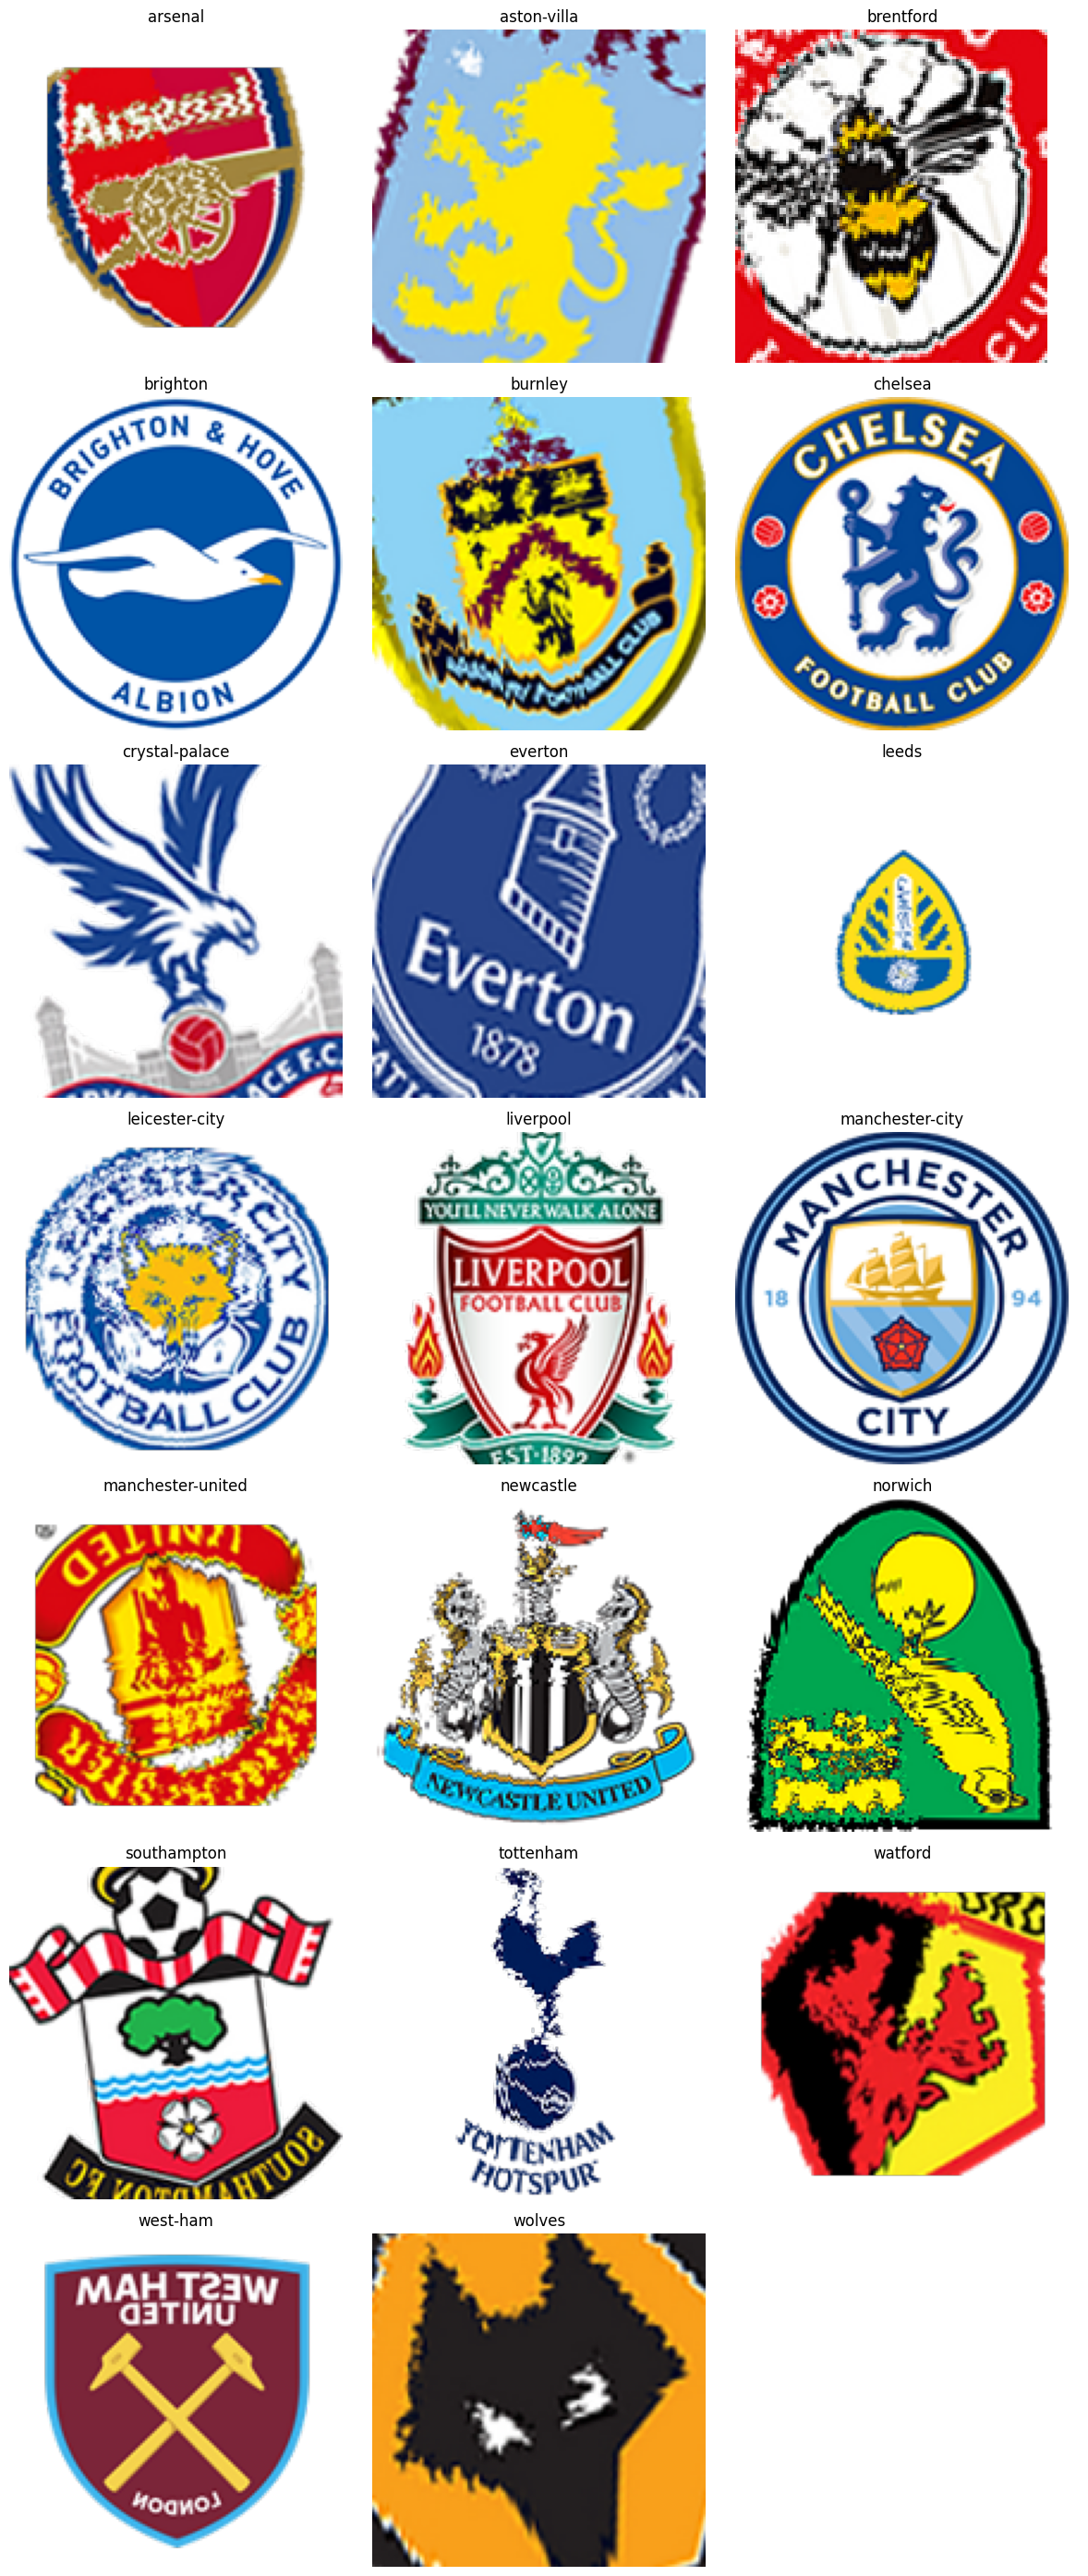

In [10]:
try:
    if not club_image_paths:
        raise NameError("club_image_paths is empty or not defined.")
except NameError:
    print("Error: club_image_paths not found. Please run Cell 1 first.")
    raise


num_clubs = len(club_image_paths)
cols = 3
rows = (num_clubs + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for idx, (club, image_paths) in enumerate(club_image_paths.items()):
    if image_paths:
        img_path = random.choice(image_paths)
        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(club)
            axes[idx].axis("off")
            print(f"Displaying {club} image: {img_path} ({img.size[0]}x{img.size[1]} pixels)")
        except Exception as e:
            print(f"Error displaying image for {club}: {e}")
            axes[idx].set_title(f"{club} (Error)")
            axes[idx].axis("off")
    else:
        axes[idx].set_title(f"{club} (No images)")
        axes[idx].axis("off")

for idx in range(len(club_image_paths), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# Crafting the Perfect Dataset (Pre-Processing)
It starts with a fixed random seed to make results repeatable, then applies several steps to get images ready for deep learning.
## Highlights
* __Fun Edits__: Random spins, flips and color changes
* __Perfect  Fit__: Images are resized, cropped and tuned to match a standard look
* __Ready to Roll__:`ImageFolder` setup organizes everything for easy training

In [11]:
torch.manual_seed(1234)

base_dir = epl_logos_dir #path of dataset

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomCrop((112, 112)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder(
    root=base_dir,
    transform=transform
)

# Splitting the EPL Logo Dataset 
This script slices the dataset into perfect portions for training, validation and testing. It takes the total number of images and divides them neatly: 70% for training,  15% for validation and the rest (15%) for testing

In [12]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print(f"Total Size: {total_size} \nTrain Size: {train_size} \nValidation Size: {val_size} \nTest size: {test_size}")

Total Size: 20000 
Train Size: 14000 
Validation Size: 3000 
Test size: 3000


# Dividing and Loading EPL Logos
This script takes the dataset and splits it into training, validation, and testing groups then loads them up for action! It uses a random split to divide the dataset and creates data loaders to feed images in batches of 32.
### Highlights
__Neat Split__:Divides the dataset into train, validation, and test sets with a random shuffle.

__Batch Power__:Loads image in chuks of 32, perfect for training, with fast processing and shuffling. 

__Quick Peek__:Shows the shape of each batch and a glimpse of the first five labels for each set

In [13]:
train_dataset, val_dataset, test_dataset = random_split(dataset,[train_size,val_size,test_size])

train_loader = DataLoader(
    train_dataset, 
    batch_size = 32, 
    shuffle=True,
    num_workers = 2, 
    pin_memory = True)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size = 32,
    shuffle = True,
    num_workers = 2,
    pin_memory = True
)

images,labels = next(iter(train_loader))
print(f"Train batch shape:{images.shape}, Labels: {labels[:5]}")

images,labels = next(iter(val_loader))
print(f"validation batch shape: {images.shape}, Labels: {labels[:5]}")

images,labels = next(iter(test_loader))
print(f"Test batch shape: {images.shape}, Labels: {labels[:5]}")

Train batch shape:torch.Size([32, 3, 112, 112]), Labels: tensor([ 9, 17, 14, 17,  1])
validation batch shape: torch.Size([32, 3, 112, 112]), Labels: tensor([11,  0,  0, 16,  4])
Test batch shape: torch.Size([32, 3, 112, 112]), Labels: tensor([ 0,  5, 11, 14, 16])


# Feature Extractor
This scripts builds a feature extraction backbone for the EPL logo CNN! It stacks convolutional layers, ReLU activations, and max pooling to process images, then uses a dummy imput to calculate the flattened feature size for downstream layers
## Highlights
__Feature Powerhouse__: Three conv layers (3→32→64→128 filters) with ReLU and pooling extract rich logo features.

__Smart Sizing__: Computes the flattened output size (25088) using a dummy 112 X 112 image.

__No Grad Needed__: Runs efficiently without gradient tracking for quick size checking

In [14]:
feature_extractor = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
)

with torch.no_grad():
    dummy = torch.randn(1, 3, 112, 112)  
    n_features = feature_extractor(dummy).view(1, -1).size(1)

print("Flattened feature size:", n_features)  # should print 25088


Flattened feature size: 25088


# Building the EPL Logo Classifier
This scripts builds the complete EPL logo classifier by combining the feature extractor with fully connected head! It flattens the extracted features, feeds them through dense layers with ReLU and dropout for robustness, and outputs predictions for each logo class. The model is sent to GPU(if available) or CPU, and it checks the output shape with a batch of training images
### Highlights
__Full Model__: Pairs the feature extractor with linear layers(n_features→128→classes) for classification.

__Robust Design__: Adds droput (0.5) to prevent overfitting and ReLu for non-linearity.

__Device Flexibility__:Runs on GPU or CPU and confirms output shape for a training batch.

In [16]:
model = nn.Sequential(
    feature_extractor,
    nn.Flatten(),
    nn.Linear(n_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, len(dataset.classes))
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Device used to train: {device}")
print(model)

images, labels = next(iter(train_loader))
images = images.to(device)
outputs = model(images)
print(f"Output shape: {outputs.shape}")

Device used to train: cuda
Sequential(
  (0): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=25088, out_features=128, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=128, out_features=20, bias=True)
)
Output shape: torch.Size([32, 20])


# Kicking Off the Training
This scripts kicks off the training process for the EPL logo CNN! It uses crossEntropyLoss to gauge prediction accuracy and the adam optimizer with a 0.001 learning rate to tweak the model. Plus, it sets up lists to track training and validation losses and accuracies over time

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training Loop for EPL Logo classifier
This scripts trains the EPL logo CNN over 15 epochs. It loops through the training data, updating the model with each batch, while tracking losses and accuracies. Then it switch to evaluation mod to test the validation dataset, keeping tabs on performance without tweaking the model. The snapshot of training and validation loss and accuracy is printed in every epoch.
### Highlights 
__Full Training Cycle__: Runs 15 epochs, optimizing the model with each batch of images. 

__performance Tracking__: Captures loss and accuracy for both training and validation phases.

__Clear Updates__: Prints Progress per epoch, showing how the model improves

In [18]:
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images,labels in train_loader:
        images,labels = images.to(device) , labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _,predicted = torch.max(outputs,1)
        train_total += labels.size(0)
        train_correct += (predicted ==labels).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    #validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images,labels in val_loader:
            images,labels = images.to(device),labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            val_loss += loss.item()
            _,predicted = torch.max(outputs,1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

Epoch 1/15, Train Loss: 1.7347, Train Acc: 45.51%, Val Loss: 0.6177, Val Acc: 81.73%
Epoch 2/15, Train Loss: 0.7517, Train Acc: 76.04%, Val Loss: 0.3377, Val Acc: 91.00%
Epoch 3/15, Train Loss: 0.5207, Train Acc: 82.88%, Val Loss: 0.2291, Val Acc: 93.23%
Epoch 4/15, Train Loss: 0.4227, Train Acc: 86.75%, Val Loss: 0.1509, Val Acc: 96.03%
Epoch 5/15, Train Loss: 0.3455, Train Acc: 89.06%, Val Loss: 0.1574, Val Acc: 95.43%
Epoch 6/15, Train Loss: 0.3167, Train Acc: 90.13%, Val Loss: 0.1127, Val Acc: 96.57%
Epoch 7/15, Train Loss: 0.2856, Train Acc: 91.09%, Val Loss: 0.1287, Val Acc: 96.77%
Epoch 8/15, Train Loss: 0.2531, Train Acc: 92.04%, Val Loss: 0.1058, Val Acc: 96.57%
Epoch 9/15, Train Loss: 0.2348, Train Acc: 92.76%, Val Loss: 0.0945, Val Acc: 97.43%
Epoch 10/15, Train Loss: 0.2135, Train Acc: 93.54%, Val Loss: 0.0738, Val Acc: 97.73%
Epoch 11/15, Train Loss: 0.2033, Train Acc: 93.91%, Val Loss: 0.0615, Val Acc: 98.37%
Epoch 12/15, Train Loss: 0.1889, Train Acc: 94.09%, Val Loss: 0

# Testing After Training
With the model in evaluation mode, it processes the test dataset, calculating the loss and accuracy without tweaking the model’s weights. It sums up the results and prints the final test loss and accuracy.

In [19]:
# Test phase (after training)
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_accuracy = 100 * test_correct / test_total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0649, Test Accuracy: 98.10%


# Saving the Model
This scripts saves the models for future use or improvement

In [20]:
torch.save(model.state_dict(), "epl_logo_cnn.pth")
print("Model saved to epl_logo_cnn.pth")

Model saved to epl_logo_cnn.pth


# Visualizing the progress
This sleek script creates a side-by-side plot to showcase the EPL logo classifier’s training journey! It graphs the training and validation losses on one side and accuracies on the other, making it easy to see how the model improves over epochs.

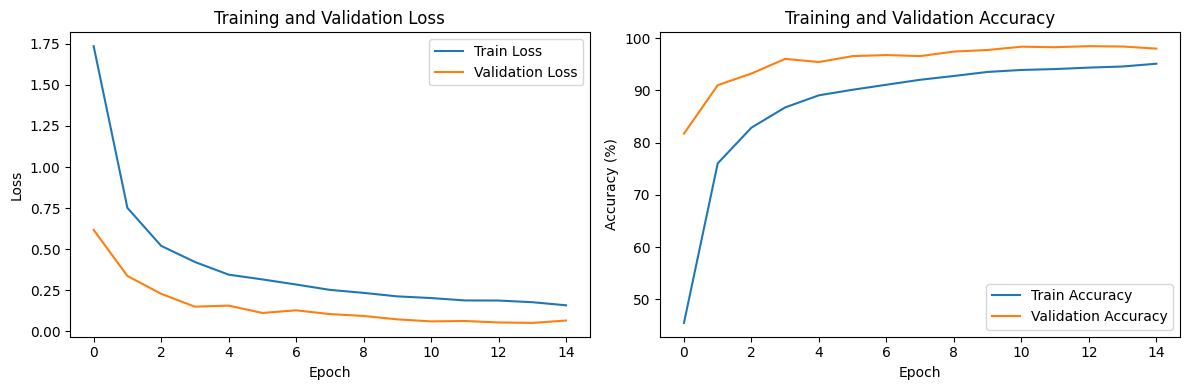

In [21]:
# Plotting training progress
plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()